<a href="https://colab.research.google.com/github/samreenfathima18/Guvi-Final-project/blob/main/Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
import joblib
import os

from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

warnings.filterwarnings("ignore")

**Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Load Prepared Data**

In [ ]:
DATA_PATH = "/content/drive/MyDrive/Enterprise_Retail_Intelligence/prepared_data/"
RESULTS_PATH = "/content/drive/MyDrive/Enterprise_Retail_Intelligence/results/"


X_train = pd.read_parquet(DATA_PATH + "X_train.parquet")
X_valid = pd.read_parquet(DATA_PATH + "X_valid.parquet")
X_test = pd.read_parquet(DATA_PATH + "X_test.parquet")

y_train = pd.read_parquet(DATA_PATH + "y_train.parquet")["sales"]
y_valid = pd.read_parquet(DATA_PATH + "y_valid.parquet")["sales"]
y_test = pd.read_parquet(DATA_PATH + "y_test.parquet")["sales"]

print(X_train.shape)
print(X_valid.shape)
print(X_test.shape)

(4082915, 36)
(874911, 36)
(874911, 36)


**Remove Date Column**

In [ ]:
if "date" in X_train.columns:
    X_train = X_train.drop(columns=["date"])
    X_valid = X_valid.drop(columns=["date"])
    X_test = X_test.drop(columns=["date"])

**Final Data Validation**

In [ ]:
for name, data in {
    "Train": X_train,
    "Validation": X_valid,
    "Test": X_test
}.items():

    print("="*30)
    print(name)

    print("Missing :", data.isnull().sum().sum())

    print("Infinity :", np.isinf(data.select_dtypes(include=np.number)).sum().sum())

Train
Missing : 0
Infinity : 0
Validation
Missing : 0
Infinity : 0
Test
Missing : 0
Infinity : 0


**Development Mode**

In [ ]:
DEVELOPMENT_MODE = False

if DEVELOPMENT_MODE:

    X_train_model = X_train.sample(
        n=300000,
        random_state=42
    )

    y_train_model = y_train.loc[X_train_model.index]

else:

    X_train_model = X_train
    y_train_model = y_train

**Train Model**

In [ ]:
lr_model = LinearRegression()

lr_model.fit(
    X_train_model,
    y_train_model
)

LinearRegression()

**Validation Predictions**

In [ ]:
valid_pred = lr_model.predict(X_valid)

**Test Predictions**

In [ ]:
test_pred = lr_model.predict(X_test)

**Evaluation Function**

In [ ]:
def evaluate(actual, pred):

    mae = mean_absolute_error(actual, pred)

    rmse = np.sqrt(
        mean_squared_error(actual, pred)
    )

    mape = (
        np.mean(
            np.abs(
                (actual - pred) /
                np.maximum(actual, 1)
            )
        ) * 100
    )

    r2 = r2_score(actual, pred)

    return mae, rmse, mape, r2

**Validation Metrics**

In [ ]:
mae, rmse, mape, r2 = evaluate(
    y_valid,
    valid_pred
)

print("="*50)
print("Validation Performance")
print("="*50)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.4f}")

Validation Performance
MAE  : 1.0553
RMSE : 2.2288
MAPE : 59.63%
R²   : 0.6496


**Test Metrics**

In [ ]:
mae, rmse, mape, r2 = evaluate(
    y_test,
    test_pred
)

print("="*50)
print("Test Performance")
print("="*50)

print(f"MAE  : {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAPE : {mape:.2f}%")
print(f"R²   : {r2:.4f}")

Test Performance
MAE  : 1.0538
RMSE : 2.1349
MAPE : 59.38%
R²   : 0.6367


**Save Metrics**

In [ ]:
import pandas as pd
import os

RESULTS_PATH = "/content/drive/MyDrive/Enterprise_Retail_Intelligence/results/"
os.makedirs(RESULTS_PATH, exist_ok=True)

metrics_df = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MAE": [mae],
    "RMSE": [rmse],
    "MAPE": [mape],
    "R2": [r2]
})

metrics_df.to_csv(
    RESULTS_PATH + "linear_regression_metrics.csv",
    index=False
)

print("✅ Linear Regression metrics saved successfully!")
metrics_df

✅ Linear Regression metrics saved successfully!


,Model,MAE,RMSE,MAPE,R2
0,Linear Regression,1.053811,2.134851,59.3785,0.636731


**Actual vs Predicted**

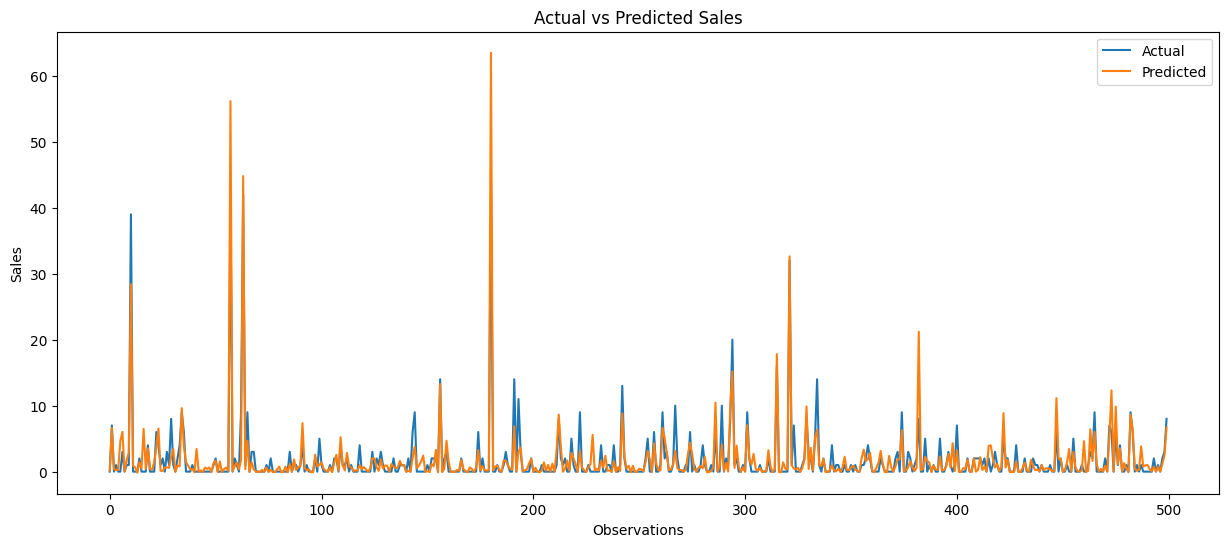

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(
    y_test.iloc[:500].values,
    label="Actual"
)

plt.plot(
    test_pred[:500],
    label="Predicted"
)

plt.title("Actual vs Predicted Sales")

plt.xlabel("Observations")

plt.ylabel("Sales")

plt.legend()

plt.show()

**Save Predictions**

In [ ]:
predictions_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": test_pred
})

predictions_df.to_csv(
    RESULTS_PATH + "linear_regression_predictions.csv",
    index=False
)

print("✅ Linear Regression predictions saved successfully!")
predictions_df.head()

✅ Linear Regression predictions saved successfully!


,Actual,Predicted
0,0,0.159974
1,7,6.624256
2,0,0.393576
3,1,0.224384
4,0,0.239525


**Residual Distribution**

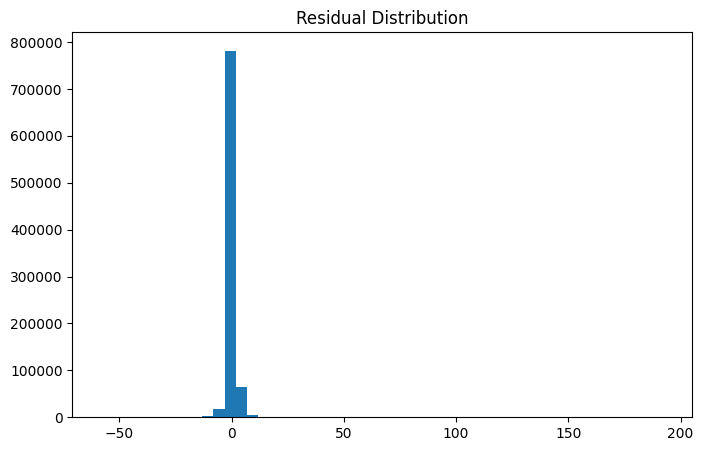

In [ ]:
errors = y_test.values - test_pred

plt.figure(figsize=(8,5))

plt.hist(
    errors,
    bins=50
)

plt.title("Residual Distribution")

plt.show()

**Feature Importance**

In [ ]:
importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Coefficient": lr_model.coef_

})

importance["Absolute"] = importance["Coefficient"].abs()

importance = importance.sort_values(
    "Absolute",
    ascending=False
)

importance.head(20)

,Feature,Coefficient,Absolute
24,rolling_mean_7,0.523831,0.523831
17,is_weekend,0.370587,0.370587
20,lag_1,0.233846,0.233846
25,rolling_std_7,-0.192942,0.192942
13,sell_price,0.154968,0.154968
32,price_rolling_mean,-0.154329,0.154329
31,price_diff,-0.148357,0.148357
18,is_month_start,0.109051,0.109051
33,is_event,-0.109046,0.109046
22,lag_14,0.106299,0.106299


**Save Model**

In [ ]:
MODEL_PATH = "/content/drive/MyDrive/Enterprise_Retail_Intelligence/models/"

os.makedirs(MODEL_PATH, exist_ok=True)

joblib.dump(
    lr_model,
    MODEL_PATH + "LinearRegression.pkl"
)

['/content/drive/MyDrive/Enterprise_Retail_Intelligence/models/LinearRegression.pkl']